In [1]:
# In arXiv:1208.0928
# Class 2 is defined as errors in the measure qubit, data qubit CNOT operations


In [2]:
from utils import *

import sinter # makes implementation faster
import os
from typing import List

In [3]:
def surface_code_memory(p:float, # error rate 
                        d: int, # code distance
                        num_rounds = None, # number of repeated measurements
                        ):
    
    if not round:
        num_rounds = 3 * d

    num_qubits = (2*d-1)**2

    num_measure_q = 2 * d * (d - 1)
    num_data_q = 2 * d**2 - 2 * d + 1

    nrows = 2*d - 1; ncols = 2*d - 1

    qindex = np.arange(0, num_qubits, 1)
    qgrid = np.reshape(qindex, (nrows, ncols)).T


    # Build coordinate lookup dictionary
    coord_map = {}
    for i in range(nrows):
        for j in range(ncols):
            coord_map[qgrid[i, j]] = (i, j)


    # Build coordinates
    qposition = [f"QUBIT_COORDS({j}, {i}, 0) {qgrid[j,i]}" 
                    for i in range(nrows) 
                    for j in range(ncols)]
    qcoords = "\n".join(qposition)

    # Then use the dictionary for lookups
    measure_q = []
    data_q = []
    data_q_index = []
    measure_q_index = []

    for i in range(1, num_qubits, 2):
        x, y = coord_map[i]
        measure_q.append([x, y, i])
        measure_q_index.append(i)


    for i in range(0, num_qubits, 2):
        x, y = coord_map[i]
        data_q.append([x, y, i])
        data_q_index.append(i)
        

    zmeasure_q = np.array([[x, y, qgrid[x,y]]
                for y in range(1, nrows - 1, 2)
                for x in range(0, ncols, 2)], dtype =int)


    xmeasure_q = np.array([[x, y, qgrid[x,y]]
                for y in range(0, nrows, 2)
                for x in range(1, ncols - 1, 2)], dtype = int)

    measure_hist = np.zeros(num_qubits, dtype = int)

    j  = 0 

    for i in range(1,num_qubits,2):
        measure_hist[i] = -len(measure_q) + j
        j +=1


    # stabilizer measurement instructions =========

    # step 01

    hadamard_on_xmeasure_q = hadamard(qubits=xmeasure_q[:,2]) # applies hadamard on x stabilizer measure qubits
    # hadamard_on_xmeasure_q += depolarize1(qubits=xmeasure_q[:,2], error_rate=p) # add depolarizing noise

    id_on_zmeasure_q = identity(qubits=zmeasure_q[:,2]) # works as a idle step 
    # id_on_zmeasure_q +=  depolarize1(qubits=zmeasure_q[:,2], error_rate=p) # add depolarizing noise

    id_on_data_q = identity(qubits=data_q_index)
    # id_on_data_q += depolarize1(qubits=data_q_index, error_rate=p)

    # step 02


    cnot01_q = [(qgrid[j,i], qgrid[j+1,i]) 
                for i in range(0, nrows, 2)
                for j in range(1, ncols, 2)] + [(qgrid[j + 1, i], qgrid[j, i])
                                                for i in range(1, nrows, 2)
                                                for j in range(0, ncols - 1, 2)]

    cnot01 = cnot(qubits=cnot01_q)
    idle_q01 = [qgrid[0, i] for i in range(0, nrows, 2)] + [qgrid[-1, i] for i in range(1, nrows, 2)]
    cnot01 += identity(qubits=idle_q01)
    cnot01 += depolarize2(qubits=cnot01_q, error_rate=p)
    # cnot01 += depolarize1(
    #     idle_q01, error_rate= p
    # )


    cnot02_q = [(qgrid[x, y], qgrid[x, y + 1])
                for x in range(1, nrows, 2)
                for y in range(0, ncols - 2, 2)] +[(qgrid[x, y + 1], qgrid[x, y])
                                                for x in range(0, nrows, 2)
                                                for y in range(1, ncols, 2)]

    cnot02 = cnot(qubits=cnot02_q)
    idle_q02 = [qgrid[i, 0] for i in range(0, nrows, 2)] + [qgrid[i, -1] for i in range(1, nrows, 2)]
    cnot02 += identity(qubits=idle_q02)
    cnot02 += depolarize2(qubits=cnot02_q, error_rate=p)
    # cnot02 += depolarize1(
    #     idle_q02, error_rate= p
    # )


    cnot03_q = [(qgrid[j,i], qgrid[j,i+1])
                for i in range(0, nrows-1, 2)
                for j in range(0, ncols, 2)]  + [(qgrid[j,i+1], qgrid[j,i])
                                                for i in range(1, nrows-1, 2)
                                                for j in range(1, ncols, 2)]



    cnot03 = cnot(qubits=cnot03_q)
    idle_q03 = [qgrid[i, -1] for i in range(0, nrows, 2)] + [qgrid[i, 0] for i in range(1, nrows, 2)]
    cnot03 += identity(qubits=idle_q03)
    cnot03 += depolarize2(qubits=cnot03_q, error_rate=p)
    # cnot03 += depolarize1(
    #     idle_q03, error_rate= p
    # )





    cnot04_q = [(qgrid[j+1,i], qgrid[j,i])
                for i in range(0, nrows, 2)
                for j in range(0, ncols-1, 2)]  + [(qgrid[j,i], qgrid[j+1,i])
                                                for i in range(1, nrows, 2)
                                                for j in range(1, ncols-1, 2)]


    cnot04 = cnot(qubits=cnot04_q)
    idle_q04 = [qgrid[0, i] for i in range(1, nrows, 2)] + [qgrid[-1, i] for i in range(0, nrows, 2)]
    cnot04 += identity(qubits=idle_q04)
    cnot04 += depolarize2(qubits=cnot04_q, error_rate=p)
    # cnot04 += depolarize1(
    #     idle_q04, error_rate= p
    # )

    measure_measure_q = measure_z(qubits=zmeasure_q[:,2], error_rate=0, reset=False) + measure_z(qubits=xmeasure_q[:,2], error_rate=0, reset=False)

    reset_measure_q =  reset_z(qubits=zmeasure_q[:,2], reset_error=0) + reset_z(qubits=xmeasure_q[:,2], reset_error=0)



    measure_stabilizers = hadamard_on_xmeasure_q + id_on_zmeasure_q + id_on_data_q +  tick()
    measure_stabilizers += cnot01 + tick()
    measure_stabilizers += cnot02 + tick()
    measure_stabilizers += cnot03 + tick()
    measure_stabilizers += cnot04 + tick()
    measure_stabilizers += hadamard_on_xmeasure_q + id_on_zmeasure_q + id_on_data_q +  tick()
    measure_stabilizers += measure_measure_q + tick()
    measure_stabilizers += reset_measure_q + tick()






    circ_script = ''

    circ_script += qcoords 

    circ_script += reset_x(qubits=data_q_index, reset_error=0) 
    circ_script += reset_z(qubits=measure_q_index, reset_error=0) + tick()

    circ_script += measure_stabilizers



    # detectors for initial X stabilizers

    initial_detectors = ''

    for i in range(int(num_measure_q/2)):
        initial_detectors += f'DETECTOR({xmeasure_q[i, 0]}, {xmeasure_q[i, 1]}, 0) rec[{-int(num_measure_q/2) + i}]\n'

    circ_script += initial_detectors



    # stabilizer measurement for d rounds

    stab_measurement_round = f'REPEAT {num_rounds} ' + '{\n SHIFT_COORDS(0, 0, 1)\n' + f'{measure_stabilizers}'

    detectors = ''

    for i in range(int(num_measure_q/2)):
        detectors += f'DETECTOR({zmeasure_q[i, 0]}, {zmeasure_q[i, 1]}, 0) rec[{-num_measure_q + i}] rec[{-2 * num_measure_q + i}]\n'

    for i in range(int(num_measure_q/2)):
        detectors += f'DETECTOR({xmeasure_q[i, 0]}, {xmeasure_q[i, 1]}, 0) rec[{-int(num_measure_q/2) + i}] rec[{- 3 * int(num_measure_q/2) + i}]\n'


    stab_measurement_round += detectors + '}'


    circ_script += stab_measurement_round


    circ_script += measure_x(qubits=data_q_index, error_rate  = 0, reset=False)

    measure_record = [None for i in range(num_qubits)] # ith element is time when qubit i was measurement

    for i in range(int(num_measure_q/2)):
        measure_record[xmeasure_q[i, 2]] = - num_data_q - int(num_measure_q/2) + i
        measure_record[zmeasure_q[i, 2]] = - num_data_q - int(num_measure_q) + i

    for i in range(num_data_q):
        measure_record[data_q[i][2]] = - num_data_q + i


    zstabilizer_info = [] # has information about which Z stabilizer and associated data qubit they made of

    zstabilizer_info += [[qgrid[0,y], qgrid[0,y-1], qgrid[0,y+1], qgrid[1,y]] for y in range(1, ncols-1, 2)]

    zstabilizer_info += [[qgrid[x,y], qgrid[x-1,y], qgrid[x+1,y], qgrid[x,y+1], qgrid[x,y-1]]                    
                        for x in range(2,nrows-1,2) 
                        for y in range(1,ncols-1,2)]


    zstabilizer_info += [[qgrid[-1,y],qgrid[-1,y-1],qgrid[-1,y+1],qgrid[-2,y]]
                        for y in range(1,nrows - 1, 2) 
                        ]


    xstabilizer_info = [] # has information about which X stabilizer and associated data qubit they made of

    xstabilizer_info += [[qgrid[x, 0], qgrid[x -1, 0], qgrid[x+1, 0], qgrid[x, 1]] for x in range(1, nrows, 2)]

    xstabilizer_info += [[qgrid[x,y], qgrid[x-1,y], qgrid[x+1,y], qgrid[x,y+1], qgrid[x,y-1] ]
                        for y in range(2, ncols - 2, 2)
                        for x in range(1, nrows, 2)]

    xstabilizer_info += [[qgrid[x, -1], qgrid[x -1, -1], qgrid[x+1, -1], qgrid[x, -2]]
                        for x in range(1, nrows, 2)]

    final_detectors = '\nSHIFT_COORDS(0, 0, 1)\n'



    for s in xstabilizer_info:
        x, y = coord_map[s[0]]
        final_detectors += f'DETECTOR({x}, {y}, 0) '
        for ri in s:
            final_detectors += f'rec[{measure_record[ri]}] '
        final_detectors += '\n'


    circ_script += final_detectors


    zlogical = [qgrid[x, 0] for x in range(0, nrows, 2)] # requires for the Z memory experiment 

    xlogical = [qgrid[0, y] for y in range(0, ncols, 2)]


    observable = 'OBSERVABLE_INCLUDE(0)'

    for i in range(d):

        observable += f' rec[{measure_record[xlogical[i]]}]'


    circ_script += observable


    circ = stim.Circuit(circ_script)


    return circ

In [4]:
# Generates surface code circuit tasks using Stim's circuit generation.

def generate_sc_memory():
    for p in np.logspace(-3, -1.75, 7):
        for d in [3, 5, 7, 9, 11]:
            yield sinter.Task(
                circuit=surface_code_memory(p = p, d = d, num_rounds= 3 * d),
                json_metadata={
                    'p': p,
                    'd': d,
                },
            )

In [5]:
# Collect the samples (takes a few minutes).
samples = sinter.collect(
    num_workers=os.cpu_count(),
    max_shots=1_000_000,
    max_errors=1000,
    tasks=generate_sc_memory(),
    decoders=['pymatching'],
    print_progress=False,
)


In [6]:
from collections import defaultdict
import numpy as np

grouped = defaultdict(list)

for s in samples:
    d_val = s.json_metadata['d']
    p_val = s.json_metadata['p']
    
    # Handle edge case where 'errors' may be missing (as in your d=11, p=0.001)
    errors = getattr(s, 'errors', 0) or 0
    
    log_err = errors / s.shots
    
    grouped[d_val].append((p_val, log_err, s.shots))

for d_val in grouped:
    grouped[d_val].sort(key=lambda x: x[0])

d = sorted(grouped.keys())

p = []
log_err_rates = []
shots_list = []

for d_val in d:
    data = grouped[d_val]
    
    p.append(np.array([x[0] for x in data]))
    log_err_rates.append(np.array([x[1] for x in data]))
    shots_list.append(np.array([x[2] for x in data]))

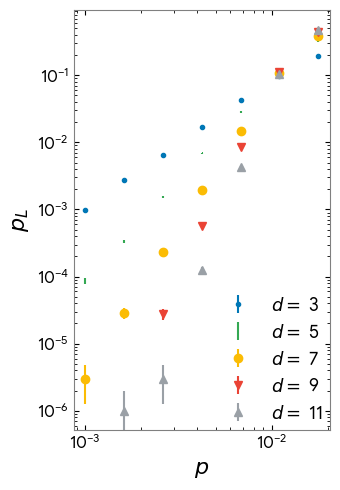

In [9]:
fig, ax = plt.subplots(figsize=(3.5,5))


for i in range(len(d)):

    log_err_di = log_err_rates[i]
    std_err = (log_err_di * (1 - log_err_di)/shots_list[i])**0.5

    ax.errorbar(p[i], 
                log_err_rates[i], 
                yerr = std_err, 
                label = rf'$d = $ {d[i]}', 
                color = google[i], 
                linestyle = '', 
                marker = marks[i]
                )

# ax.axvline(x = p_threshold, linestyle='-.', label = r'$p_{th}$', color = 'k')


for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tick_params(top=True, left=True, right=True, bottom=True,
               direction="in", axis='both', which='both', 
               labelsize=12, color='k')

ax.set_xscale('log')
ax.set_yscale('log')

font2 = {'family':'Google Sans', 'color':'black', 'size':16}

plt.xlabel(r"$p$", fontdict=font2)
plt.ylabel(r"$p_L$", fontdict=font2)


# plt.xticks([0.01, 0.02, 0.03, 0.04, 0.06], [0.01, 0.02, 0.03, 0.04, 0.06])

plt.legend(
    fontsize=13,  # Slightly smaller font for external legend
    ncol=1,  # Fewer columns for vertical space 
    loc='best', 
    frameon=False,
    borderaxespad=0.  # Removes padding between axes and legend
)   

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust right margin to make space
plt.savefig('figs/log_err_class2.jpeg',bbox_inches='tight', dpi = 500)
plt.show()

In [10]:
# Finding the threshold ----------

In [11]:
# Generates surface code circuit tasks using Stim's circuit generation.

def generate_sc_memory():
    for p in np.arange(9e-3, 2e-2, 1e-4):
        for d in [7, 11]:
            yield sinter.Task(
                circuit=surface_code_memory(p = p, d = d, num_rounds= 3 * d),
                json_metadata={
                    'p': p,
                    'd': d,
                },
            )


# Collect the samples (takes a few minutes).
samples = sinter.collect(
    num_workers=os.cpu_count(),
    max_shots=1_000_000,
    max_errors=1000,
    tasks=generate_sc_memory(),
    decoders=['pymatching'],
    print_progress=True,
)


Starting 48 workers...
220 tasks left:
  workers    decoder  eta shots_left errors_left json_metadata              
        1 pymatching    ?    1000000        1000 p=0.009,d=7                
        1 pymatching    ?    1000000        1000 p=0.009,d=11               
        1 pymatching    ?    1000000        1000 p=0.009099999999999999,d=7 
        1 pymatching    ?    1000000        1000 p=0.009099999999999999,d=11
        1 pymatching    ?    1000000        1000 p=0.009199999999999998,d=7 
        1 pymatching    ?    1000000        1000 p=0.009199999999999998,d=11
        1 pymatching    ?    1000000        1000 p=0.009299999999999998,d=7 
        1 pymatching    ?    1000000        1000 p=0.009299999999999998,d=11
        1 pymatching    ?    1000000        1000 p=0.009399999999999997,d=7 
        1 pymatching    ?    1000000        1000 p=0.009399999999999997,d=11
        1 pymatching    ?    1000000        1000 p=0.009499999999999996,d=7 
        1 pymatching    ?    1000000 

In [12]:
from collections import defaultdict
import numpy as np

grouped = defaultdict(list)

for s in samples:
    d_val = s.json_metadata['d']
    p_val = s.json_metadata['p']
    errors = getattr(s, 'errors', 0) or 0
    log_err = errors / s.shots
    grouped[d_val].append((p_val, log_err))

# sort by p
for d_val in grouped:
    grouped[d_val].sort(key=lambda x: x[0])


d1, d2 = 7, 11

p1 = np.array([x[0] for x in grouped[d1]])
e1 = np.array([x[1] for x in grouped[d1]])

p2 = np.array([x[0] for x in grouped[d2]])
e2 = np.array([x[1] for x in grouped[d2]])

# choose common p values (overlap region)
p_common = np.linspace(max(min(p1), min(p2)), min(max(p1), max(p2)), 200)

e1_interp = np.interp(p_common, p1, e1)
e2_interp = np.interp(p_common, p2, e2)

diff = e1_interp - e2_interp

# find sign change
idx = np.where(np.diff(np.sign(diff)))[0]

if len(idx) == 0:
    print("No crossing found")
else:
    i = idx[0]
    
    # linear interpolation for better estimate
    x0, x1 = p_common[i], p_common[i+1]
    y0, y1 = diff[i], diff[i+1]
    
    p_threshold = x0 - y0 * (x1 - x0) / (y1 - y0)
    print("Threshold ≈", p_threshold)
    

Threshold ≈ 0.011348046384266095
